# 03 — Ablations & Inference

Summary of the 9-experiment hyperparameter sweep and interactive inference examples.

In [5]:
import json
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt

with open('../results/metrics.json') as f:
    metrics = json.load(f)

df = pd.DataFrame(metrics['ablations'])
df

,exp,lr,dropout,epochs,batch,max_len,checkpoint,val_acc,test_acc
0,1,0.00002,0.3,3,32,256,base,NaN,0.9089
1,2,0.00001,0.2,4,32,256,base,NaN,0.8956
2,3,0.00002,0.4,2,64,256,base,0.8950,NaN
3,4,0.00002,0.3,5,32,256,base,0.9114,0.9067
4,5,0.00002,0.3,3,32,256,sst-2,0.9048,0.9119
5,6,0.00003,0.2,2,32,256,sst-2,0.8930,0.9037
6,7,0.00001,0.1,3,32,256,sst-2,0.9006,0.9078
7,8,0.00002,0.3,3,32,256,sst-2,0.9008,0.9110
8,9,0.00002,0.3,3,16,512,sst-2,0.9158,0.9213
9,10,0.00002,0.3,3,16,512,sst-2,0.9244,0.9289


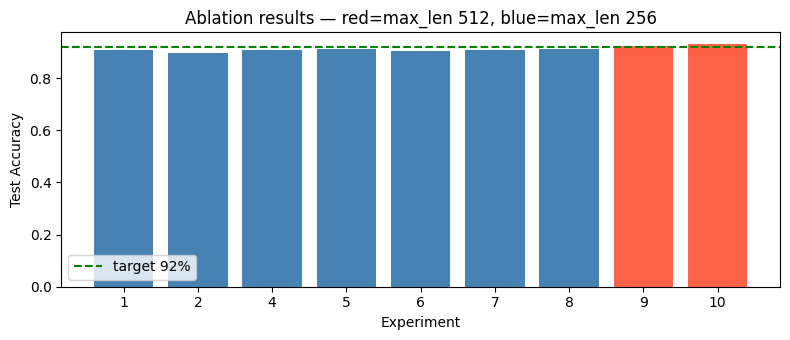

In [6]:
# Key finding: MAX_LENGTH=512 vs 256
df_test = df.dropna(subset=['test_acc'])

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ['steelblue' if m == 256 else 'tomato' for m in df_test['max_len']]
ax.bar(df_test['exp'].astype(str), df_test['test_acc'], color=colors)
ax.axhline(0.92, linestyle='--', color='green', label='target 92%')
ax.set_xlabel('Experiment'); ax.set_ylabel('Test Accuracy')
ax.set_title('Ablation results — red=max_len 512, blue=max_len 256')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/ablations.png', dpi=120)
plt.show()

In [7]:
print(f"Best test accuracy: {metrics['test_acc']*100:.2f}%")
print(f"Best val  accuracy: {metrics['val_acc']*100:.2f}%")

Best test accuracy: 92.89%
Best val  accuracy: 92.44%


## Inference examples

In [8]:
from src.utils import load_model, predict, predict_batch

model, tokenizer = load_model(
    checkpoint_path='../checkpoints/best.pt',
    model_checkpoint='distilbert-base-uncased-finetuned-sst-2-english',
)
print('Model loaded')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6971.45it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased-finetuned-sst-2-english
Key                   | Status     |  | 
----------------------+------------+--+-
classifier.weight     | UNEXPECTED |  | 
pre_classifier.weight | UNEXPECTED |  | 
classifier.bias       | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded


In [9]:
text = 'This movie was absolutely amazing!'
label, conf = predict(text, model, tokenizer)
print(f'{label} ({conf:.2%}) — {text}')

positive (99.39%) — This movie was absolutely amazing!


In [10]:
reviews = [
    'Terrible waste of time',
    "Best film I've seen this year",
    'Not bad, but could be better',
]
results = predict_batch(reviews, model, tokenizer)
for text, (label, conf) in zip(reviews, results):
    print(f'{label:8} ({conf:.2%}) — {text}')

negative (99.94%) — Terrible waste of time
positive (99.73%) — Best film I've seen this year
negative (72.52%) — Not bad, but could be better
